# 01 -- EDA train

## Постановка задачи

Мы решаем задачу регрессии задержки общественного транспорта. Одна прогнозная точка задается парой `(tr_id, T)` -- конкретным ТС и моментом, в который нужно построить прогноз.

Для каждой точки известны:

1. `T` -- момент прогноза;
2. `target_stop_id` -- ID конкретного приезда ТС на остановку по расписанию. Берется первый такой приезд, время которого попадает в окно $(T + 10\text{ мин},\ T + 15\text{ мин}]$;
3. `target_time_begin` -- время, когда ТС должно приехать на эту остановку по расписанию;
4. `cur_dev_s` -- последнее известное к моменту `T` отклонение ТС от расписания.

Наша задача -- предсказать, на сколько секунд фактическое прибытие на target-остановку будет отличаться от расписания:

$$
\text{target\_delay\_s} = \text{time\_fact\_begin} - \text{time\_begin}.
$$

Положительное значение означает опоздание, отрицательное -- прибытие раньше расписания. Основная метрика -- **MAE в секундах**.

`target_class` -- дополнительная разметка: `early < -60`, `ontime` от `-60` до `120`, `late > 120` секунд. Основная модель предсказывает непрерывный `target_delay_s`.

### Ограничение по времени

Для точки `(tr_id, T)` я использую только информацию, которая уже была доступна к `T`. Будущая телеметрия и `time_fact_begin` дают leakage. Для телеметрии важно учитывать и `receive_time`: пакет нельзя использовать раньше момента, когда система его реально получила.


## 1. Как устроена раздача

В раздаче есть три части.

| Часть | Телеметрия | Расписание | Точки для прогноза | Ответ | Для чего использую |
|---|---|---|---|---|---|
| `train` | `train/traffic.csv` | `train/schedule.csv` -- расписание + фактические прибытия | `labels/labels_train.csv` | есть | EDA и обучение |
| `test` | `test/traffic.csv` | `test/schedule.csv` -- расписание + фактические прибытия | `labels/labels_test.csv` | есть | локальная проверка модели |
| `validate` | `validate/traffic.csv` | `validate/schedule_plan.csv` -- только расписание | `validate/points.csv` | скрыт | финальный прогноз |

В этом ноутбуке я анализирую **только train**. `test` оставляю для отдельной проверки качества, `validate` -- для финального инференса.

По описанию данных `train` содержит реальные и синтетические ТС. `test` и `validate` нужны для проверки на реальных данных. В `traffic.csv` также есть ТС, для которых нет строк в labels -- они не являются отдельными объектами обучения, но их движение может давать контекст о дорожной ситуации.

### Как связаны таблицы train

`labels_train.csv` задает конкретные моменты, для которых мы должны делать прогноз. Для каждой такой строки:

1. по `tr_id` я беру историю движения этого ТС из `traffic.csv` до момента `T`;
2. `target_stop_id` указывает на строку `schedule.csv` с нужным будущим приездом на остановку;
3. `target_time_begin` -- время этого приезда по расписанию;
4. в train фактическое время приезда лежит в `schedule.time_fact_begin`;
5. разница между фактическим и запланированным временем дает `target_delay_s`.

```text
traffic.csv
  история движения ТС до T
          |
        tr_id
          |
          v
labels_train.csv ----------------> строка, для которой строю прогноз
  tr_id, T, target_stop_id         target_delay_s
               |
               | target_stop_id = tt_action_item_id
               v
schedule.csv
  остановка + время по расписанию + фактическое время приезда
```

`time_fact_begin` доступно только в размеченных данных и нужно для target/EDA. В признаки модели его включать нельзя.


### Поля `traffic.csv`

Одна строка -- один телематический пакет от ТС.

| Поле | Смысл | Значения / единицы |
|---|---|---|
| `packet_id` | ID пакета | технический идентификатор, читаю строкой |
| `tr_id` | ID транспортного средства | основной ключ ТС |
| `unit_id` | ID бортового терминала | идентификатор устройства |
| `event_time` | время события | timestamp |
| `device_event_id` | код события устройства | техническое поле |
| `location_valid` | достоверность GPS | `True / False` |
| `gps_time` | время GPS-фиксации | timestamp, может отсутствовать |
| `lon`, `lat` | координаты | градусы |
| `alt` | высота | метры |
| `speed` | скорость | км/ч |
| `heading` | курс | градусы, примерно `[0, 360]` |
| `receive_time` | время получения пакета | timestamp |
| `is_hist_data` | исторический пакет | `True / False` |

`location_valid=False` рассматриваю отдельно: ненулевые координаты еще не означают, что позиция достоверна.

### Поля `schedule.csv`

Одна строка -- один конкретный приезд ТС на остановку, который есть в расписании.

| Поле | Смысл | Значения / единицы |
|---|---|---|
| `tt_action_item_id` | ID этого запланированного приезда | совпадает с `target_stop_id`, если именно его нужно прогнозировать |
| `time_begin` | когда ТС должно приехать по расписанию | timestamp |
| `time_fact_begin` | когда ТС реально приехало | timestamp, использую только для target и EDA |
| `order_date` | дата расписания | date |
| `manual_fill` | запись заполнялась вручную | `True / False` |
| `tr_id` | ID ТС | связывает расписание с телеметрией и labels |
| `geom` | координаты остановки | WKT `POINT (lon lat)` |
| `building_address` | адрес остановки | строка, возможны пропуски |

`tt_action_item_id` относится не просто к физической остановке, а к конкретному приезду конкретного ТС в конкретное время. Поэтому одна и та же остановка встречается в `schedule.csv` много раз.


### Поля `labels_train.csv`

Одна строка -- один момент, для которого нужно предсказать будущую задержку.

| Поле | Смысл | Значения / единицы |
|---|---|---|
| `sample_id` | ID строки задачи | уникальная строка |
| `tr_id` | ID ТС | по нему нахожу телеметрию и расписание этого ТС |
| `T` | момент, в который строю прогноз | timestamp |
| `target_stop_id` | ID будущего приезда на остановку, для которого нужен прогноз | `tt_action_item_id` из `schedule.csv` |
| `target_time_begin` | когда ТС должно приехать туда по расписанию | timestamp |
| `cur_dev_s` | последнее известное отклонение от расписания к моменту `T` | секунды |
| `target_delay_s` | фактическое отклонение от расписания на target-остановке | секунды, **target** |
| `target_class` | грубый класс результата | `early`, `ontime`, `late` |

`cur_dev_s` -- естественный baseline: если ничего больше не учитывать, можно ожидать похожее отклонение через 10--15 минут. Но за это время задержка может как накопиться, так и сократиться, поэтому одной этой величины недостаточно.


## 2. Загрузка train

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

EDA_SEED = 143
np.random.seed(EDA_SEED)

plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


In [2]:
eda_traffic = pd.read_csv(
    '../dataset/train/traffic.csv',
    dtype={'packet_id': 'string'},
    parse_dates=['event_time', 'gps_time', 'receive_time']
)

eda_schedule = pd.read_csv(
    '../dataset/train/schedule.csv',
    parse_dates=['time_begin', 'time_fact_begin', 'order_date']
)

eda_labels = pd.read_csv(
    '../dataset/labels/labels_train.csv',
    parse_dates=['T', 'target_time_begin']
)

In [3]:
pd.DataFrame({
    'rows': [len(eda_traffic), len(eda_schedule), len(eda_labels)],
    'columns': [eda_traffic.shape[1], eda_schedule.shape[1], eda_labels.shape[1]],
    'vehicles': [eda_traffic.tr_id.nunique(), eda_schedule.tr_id.nunique(), eda_labels.tr_id.nunique()],
    'memory_mb': [
        eda_traffic.memory_usage(deep=True).sum() / 2**20,
        eda_schedule.memory_usage(deep=True).sum() / 2**20,
        eda_labels.memory_usage(deep=True).sum() / 2**20,
    ]
}, index=['traffic', 'schedule', 'labels'])

,rows,columns,vehicles,memory_mb
traffic,287849,14,56,42.239
schedule,16674,8,39,3.485
labels,4434,8,39,0.715


В train телеметрия сильно крупнее остальных таблиц: около 288 тыс. пакетов против 16.7 тыс. приездов и 4.4 тыс. прогнозных точек. В `traffic` 56 ТС, а в `schedule` и `labels` по 39 -- оставшиеся 17 ТС не имеют target и могут использоваться как контекст.

In [4]:
eda_traffic.head()

,packet_id,tr_id,unit_id,event_time,device_event_id,location_valid,gps_time,lon,lat,alt,speed,heading,receive_time,is_hist_data
0,-5517330596515664264,115106,664030,2026-01-06 12:30:31.462764,0,False,NaT,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:30:31.462771,False
1,-5517330596515614428,116057,794446,2026-01-06 12:32:00.058242,0,False,NaT,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:32:00.058249,False
2,-5517330596515667265,116445,663271,2026-01-06 12:30:26.176861,0,False,NaT,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:30:26.176865,False
3,-5517330596515596171,118726,1112060,2026-01-06 12:32:31.682087,0,False,NaT,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:32:31.682091,False
4,-5517330596515637929,119145,668372,2026-01-06 12:31:18.279263,0,False,NaT,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:31:18.279269,False


In [5]:
eda_schedule.head()

,tt_action_item_id,time_begin,time_fact_begin,order_date,manual_fill,tr_id,geom,building_address
0,53699433970,2026-01-06 06:36:00,2026-01-06 06:39:01,2026-01-06,True,122658,POINT (37.43070705 55.8040083),"Строгинское ш., д.1"
1,53699433974,2026-01-06 06:41:00,2026-01-06 06:44:01,2026-01-06,True,122658,POINT (37.46330869 55.80892705),"ул. Маршала Василевского, д.17"
2,53699433972,2026-01-06 06:38:00,2026-01-06 06:41:01,2026-01-06,True,122658,POINT (37.45439344 55.80550491),"Новощукинская ул., д.7"
3,53699456537,2026-01-06 13:05:00,2026-01-06 13:05:59,2026-01-06,False,133957,POINT (37.53020277 55.64161975),"ул. Миклухо-Маклая, д.53, к.1"
4,53700172912,2026-01-06 07:47:00,2026-01-06 07:45:24,2026-01-06,False,131672,POINT (37.85747284 55.73916511),"Новокосинская ул., д.17, к.3"


In [6]:
eda_labels.head()

,sample_id,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,target_class
0,122048_1767665400,122048,2026-01-06 02:10:00,53699018679,2026-01-06 02:22:00,0.000,-25.000,ontime
1,122048_1767665700,122048,2026-01-06 02:15:00,53699018678,2026-01-06 02:26:00,0.000,0.000,ontime
2,122048_1767666000,122048,2026-01-06 02:20:00,53699018687,2026-01-06 02:32:00,0.000,0.000,ontime
3,122048_1767666300,122048,2026-01-06 02:25:00,53699018692,2026-01-06 02:37:00,0.000,0.000,ontime
4,122048_1767666600,122048,2026-01-06 02:30:00,53699018689,2026-01-06 02:41:00,0.000,0.000,ontime


## 3. Проверка связей таблиц

In [7]:
eda_relation_check = eda_labels.merge(
    eda_schedule[['tt_action_item_id', 'tr_id', 'time_begin', 'time_fact_begin']],
    left_on=['target_stop_id', 'tr_id'],
    right_on=['tt_action_item_id', 'tr_id'],
    how='left'
)

eda_relation_check['schedule_delay_s'] = (
    eda_relation_check.time_fact_begin - eda_relation_check.time_begin
).dt.total_seconds()
eda_relation_check['horizon_min'] = (
    eda_relation_check.target_time_begin - eda_relation_check['T']
).dt.total_seconds() / 60

pd.Series({
    'all target visits found in schedule': eda_relation_check.tt_action_item_id.notna().all(),
    'target_time_begin == schedule.time_begin': eda_relation_check.target_time_begin.eq(eda_relation_check.time_begin).all(),
    'target_delay_s == fact - plan': np.allclose(eda_relation_check.target_delay_s, eda_relation_check.schedule_delay_s),
    'horizon in (10, 15] min': eda_relation_check.horizon_min.gt(10).all() and eda_relation_check.horizon_min.le(15).all(),
    'labels vehicles are in traffic': set(eda_labels.tr_id).issubset(set(eda_traffic.tr_id)),
})

all target visits found in schedule         True
target_time_begin == schedule.time_begin    True
target_delay_s == fact - plan               True
horizon in (10, 15] min                     True
labels vehicles are in traffic              True
dtype: bool

In [8]:
pd.Series({
    'max unit_id per tr_id': eda_traffic.groupby('tr_id').unit_id.nunique().max(),
    'max tr_id per unit_id': eda_traffic.groupby('unit_id').tr_id.nunique().max(),
})

max unit_id per tr_id    1
max tr_id per unit_id    1
dtype: int64

Связи согласованы полностью: каждая прогнозная точка находится в расписании, target и время прибытия по расписанию совпадают, горизонт действительно лежит в `(10, 15]`. В текущем train `tr_id` и `unit_id` связаны один-к-одному, поэтому `unit_id` здесь в основном дублирует идентичность ТС.

## 4. Типы, пропуски и уникальные значения

In [9]:
def eda_column_info(df):
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_share': df.isna().mean(),
        'nunique': df.nunique(dropna=False)
    })

In [10]:
eda_column_info(eda_traffic)

,dtype,missing,missing_share,nunique
packet_id,string,0,0.000,287849
tr_id,int64,0,0.000,56
unit_id,int64,0,0.000,56
event_time,datetime64[ns],0,0.000,241027
device_event_id,int64,0,0.000,1
location_valid,bool,0,0.000,2
gps_time,datetime64[us],16499,0.057,58123
lon,float64,16499,0.057,190473
lat,float64,16499,0.057,180154
alt,float64,16499,0.057,1577


In [11]:
eda_column_info(eda_schedule)

,dtype,missing,missing_share,nunique
tt_action_item_id,int64,0,0.000,16674
time_begin,datetime64[ns],0,0.000,12237
time_fact_begin,datetime64[ns],0,0.000,16342
order_date,datetime64[us],0,0.000,1
manual_fill,bool,0,0.000,2
tr_id,int64,0,0.000,39
geom,str,0,0.000,847
building_address,str,2925,0.175,602


In [12]:
eda_column_info(eda_labels)

,dtype,missing,missing_share,nunique
sample_id,str,0,0.000,4434
tr_id,int64,0,0.000,39
T,datetime64[us],0,0.000,268
target_stop_id,int64,0,0.000,4434
target_time_begin,datetime64[ns],0,0.000,3834
cur_dev_s,float64,0,0.000,657
target_delay_s,float64,0,0.000,690
target_class,str,0,0.000,3


В `labels` пропусков нет. В `traffic` все основные GPS-поля имеют одинаковые 16 499 пропусков -- 5.73% строк. В `schedule` пропуски есть только в `building_address` -- 17.54%; геометрия target-остановок заполнена полностью.

In [13]:
eda_duplicate_stats = pd.DataFrame({
    'count': [
        eda_traffic.duplicated().sum(),
        eda_schedule.duplicated().sum(),
        eda_labels.duplicated().sum(),
        eda_traffic.packet_id.duplicated().sum(),
        eda_schedule.tt_action_item_id.duplicated().sum(),
        eda_labels.sample_id.duplicated().sum(),
    ],
    'denominator': [len(eda_traffic), len(eda_schedule), len(eda_labels), len(eda_traffic), len(eda_schedule), len(eda_labels)]
}, index=[
    'traffic rows', 'schedule rows', 'labels rows',
    'packet_id', 'tt_action_item_id', 'sample_id'
])

eda_duplicate_stats['share'] = eda_duplicate_stats['count'] / eda_duplicate_stats['denominator']
eda_duplicate_stats

,count,denominator,share
traffic rows,0,287849,0.000
schedule rows,0,16674,0.000
labels rows,0,4434,0.000
packet_id,0,287849,0.000
tt_action_item_id,0,16674,0.000
sample_id,0,4434,0.000


Полных дублей и дублей основных идентификаторов нет.

In [14]:
pd.concat([
    eda_traffic.nunique().rename('traffic'),
    eda_schedule.nunique().rename('schedule'),
    eda_labels.nunique().rename('labels')
], axis=1).dropna(how='all')

,traffic,schedule,labels
packet_id,"287,849.000",NaN,NaN
tr_id,56.000,39.000,39.000
unit_id,56.000,NaN,NaN
event_time,"241,027.000",NaN,NaN
device_event_id,1.000,NaN,NaN
location_valid,2.000,NaN,NaN
gps_time,"58,122.000",NaN,NaN
lon,"190,472.000",NaN,NaN
lat,"180,153.000",NaN,NaN
alt,"1,576.000",NaN,NaN


`device_event_id` и `order_date` константны в train и сами по себе информации для модели не несут. `heading` имеет 361 уникальное значение, что соответствует целочисленному курсу от 0 до 360 градусов.

### GPS-пропуски и качество позиции

In [15]:
eda_gps_cols = ['gps_time', 'lon', 'lat', 'alt', 'speed', 'heading']
eda_all_gps_missing = eda_traffic[eda_gps_cols].isna().all(axis=1)

pd.crosstab(
    eda_traffic.location_valid,
    eda_all_gps_missing,
    rownames=['location_valid'],
    colnames=['all GPS fields missing'],
    margins=True
)

all GPS fields missing,False,True,All
location_valid,,,
False,27376,16499,43875
True,243974,0,243974
All,271350,16499,287849


In [16]:
eda_quality_stats = pd.DataFrame({
    'count': [
        (~eda_traffic.location_valid).sum(),
        eda_all_gps_missing.sum(),
        ((~eda_traffic.location_valid) & eda_traffic.lon.notna() & eda_traffic.lat.notna()).sum(),
        eda_traffic.is_hist_data.sum(),
    ]
}, index=[
    'location_valid = False',
    'all GPS fields missing',
    'invalid but lon/lat present',
    'is_hist_data = True',
])
eda_quality_stats['share'] = eda_quality_stats['count'] / len(eda_traffic)
eda_quality_stats

,count,share
location_valid = False,43875,0.152
all GPS fields missing,16499,0.057
invalid but lon/lat present,27376,0.095
is_hist_data = True,9076,0.032


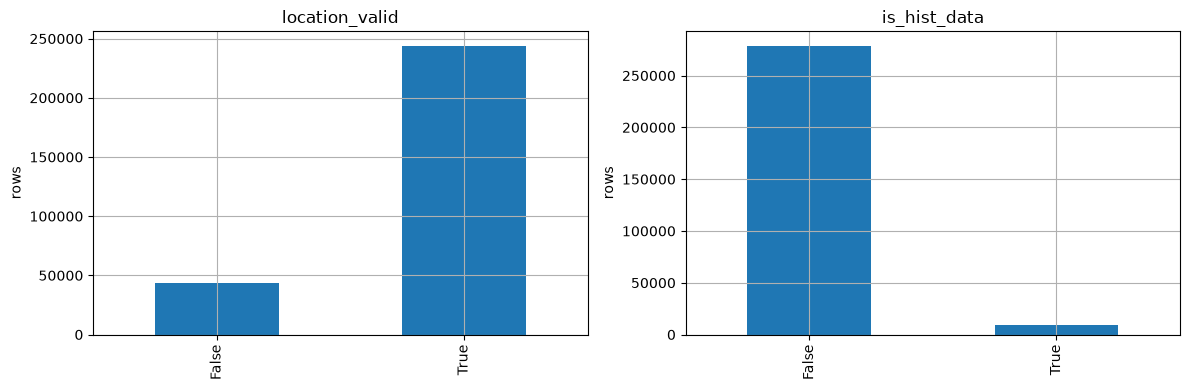

In [17]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(12, 4))

eda_traffic.location_valid.value_counts().sort_index().plot.bar(ax=eda_axes[0])
eda_axes[0].set_title('location_valid')
eda_axes[0].set_xlabel('')
eda_axes[0].set_ylabel('rows')

eda_traffic.is_hist_data.value_counts().sort_index().plot.bar(ax=eda_axes[1])
eda_axes[1].set_title('is_hist_data')
eda_axes[1].set_xlabel('')
eda_axes[1].set_ylabel('rows')

plt.tight_layout()

`location_valid=False` у 15.24% пакетов. При этом 27 376 строк -- 9.51% всей телеметрии -- содержат `lon/lat`, несмотря на невалидный флаг. Поэтому в feature engineering буду хранить и наличие координат, и явный признак качества: проверка только на `NaN` недостаточна.

## 5. Временная структура телеметрии

In [18]:
pd.DataFrame({
    'min': [eda_traffic.event_time.min(), eda_traffic.receive_time.min(), eda_schedule.time_begin.min(), eda_labels['T'].min()],
    'max': [eda_traffic.event_time.max(), eda_traffic.receive_time.max(), eda_schedule.time_begin.max(), eda_labels['T'].max()]
}, index=['traffic.event_time', 'traffic.receive_time', 'schedule.time_begin', 'labels.T'])

,min,max
traffic.event_time,2026-01-05 23:46:15.880133799,2026-01-07 00:25:58.268893882
traffic.receive_time,2026-01-05 23:46:17.042584799,2026-01-07 04:50:35.284704946
schedule.time_begin,2026-01-06 02:11:56.876587200,2026-01-07 04:21:00.000000000
labels.T,2026-01-06 02:10:00.000000000,2026-01-07 00:25:00.000000000


In [19]:
eda_traffic_time = eda_traffic.sort_values(['tr_id', 'event_time']).copy()
eda_traffic_time['event_gap_s'] = eda_traffic_time.groupby('tr_id').event_time.diff().dt.total_seconds()
eda_traffic_time['receive_lag_s'] = (eda_traffic_time.receive_time - eda_traffic_time.event_time).dt.total_seconds()

eda_traffic_time[['event_gap_s', 'receive_lag_s']].describe(
    percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .995, .999]
).T

,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.5%,99.9%,max
event_gap_s,"287,793.000",11.082,159.731,0.000,0.000,0.000,1.000,3.000,8.000,14.000,16.000,26.000,65.914,86.000,"33,978.926"
receive_lag_s,"287,849.000",42.401,"1,270.242",-276.133,-274.130,-17.062,0.000,0.990,1.663,2.428,5.291,31.025,56.287,"34,250.526","43,927.454"


Типичный поток достаточно плотный: медианный gap между соседними пакетами -- 8 секунд, p95 -- 16 секунд, p99 -- 26 секунд. Но максимум достигает нескольких часов. Для `receive_time - event_time` медиана около 1.66 секунды, а p99 уже около 31 секунды -- свежесть пакета нужно учитывать отдельно.

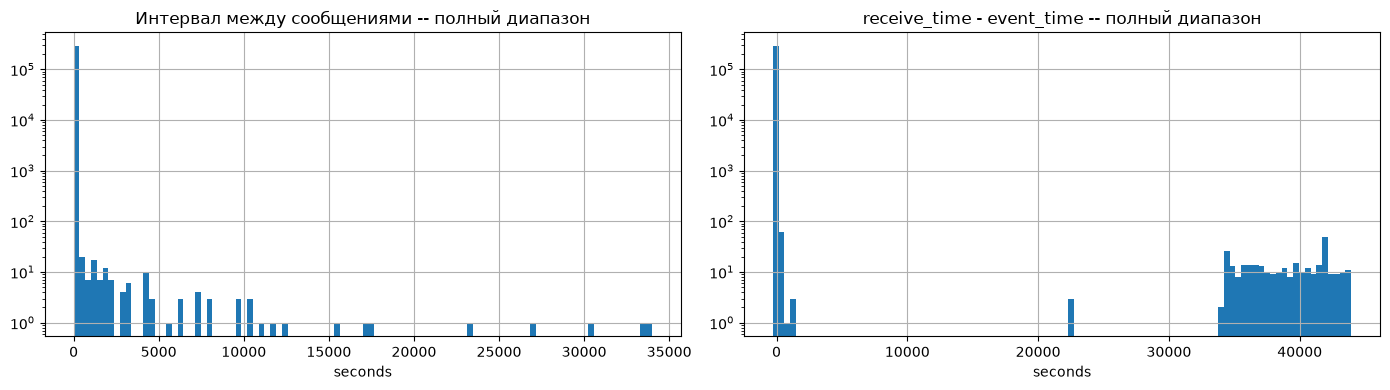

In [20]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(14, 4))

eda_axes[0].hist(eda_traffic_time.event_gap_s.dropna(), bins=100)
eda_axes[0].set_yscale('log')
eda_axes[0].set_title('Интервал между сообщениями -- полный диапазон')
eda_axes[0].set_xlabel('seconds')

eda_axes[1].hist(eda_traffic_time.receive_lag_s.dropna(), bins=100)
eda_axes[1].set_yscale('log')
eda_axes[1].set_title('receive_time - event_time -- полный диапазон')
eda_axes[1].set_xlabel('seconds')

plt.tight_layout()

In [21]:
eda_time_quality = pd.DataFrame({
    'count': [
        (eda_traffic_time.event_gap_s <= 0).sum(),
        (eda_traffic_time.receive_lag_s < 0).sum(),
        (eda_traffic_time.receive_lag_s > 30).sum(),
        eda_traffic.is_hist_data.sum(),
    ]
}, index=[
    'event_gap_s <= 0',
    'receive_lag_s < 0',
    'receive_lag_s > 30 sec',
    'historical packets',
])
eda_time_quality['share'] = eda_time_quality['count'] / len(eda_traffic)
eda_time_quality

,count,share
event_gap_s <= 0,8473,0.029
receive_lag_s < 0,10168,0.035
receive_lag_s > 30 sec,3037,0.011
historical packets,9076,0.032


Около 2.94% строк имеют нулевой gap внутри ТС, 3.53% -- отрицательный `receive_lag_s`, 1.06% приходят позже чем через 30 секунд, 3.15% помечены как исторические. Отрицательный lag считаю особенностью часов/источника, а не физически отрицательной задержкой доставки.

## 6. Числовые поля телеметрии

In [22]:
eda_traffic[['lon', 'lat', 'alt', 'speed', 'heading']].describe(
    percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .995, .999]
).T


,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.5%,99.9%,max
lon,"271,350.000",36.927,4.758,-0.000,0.000,0.000,37.190,37.423,37.508,37.706,37.826,37.861,37.865,37.886,37.890
lat,"271,350.000",54.794,7.057,-0.000,0.000,0.000,55.540,55.633,55.668,55.736,55.981,56.012,56.030,56.030,56.031
alt,"271,350.000",168.052,354.531,0.000,0.000,0.000,0.000,122.000,158.000,190.000,253.000,965.000,"1,033.000","1,666.255","65,505.000"
speed,"271,350.000",13.428,20.896,0.000,0.000,0.000,0.000,0.000,3.000,21.000,49.000,99.000,102.200,117.400,368.000
heading,"271,350.000",142.429,116.535,0.000,0.000,0.000,0.000,24.000,132.000,238.000,340.000,354.000,357.000,359.000,360.000


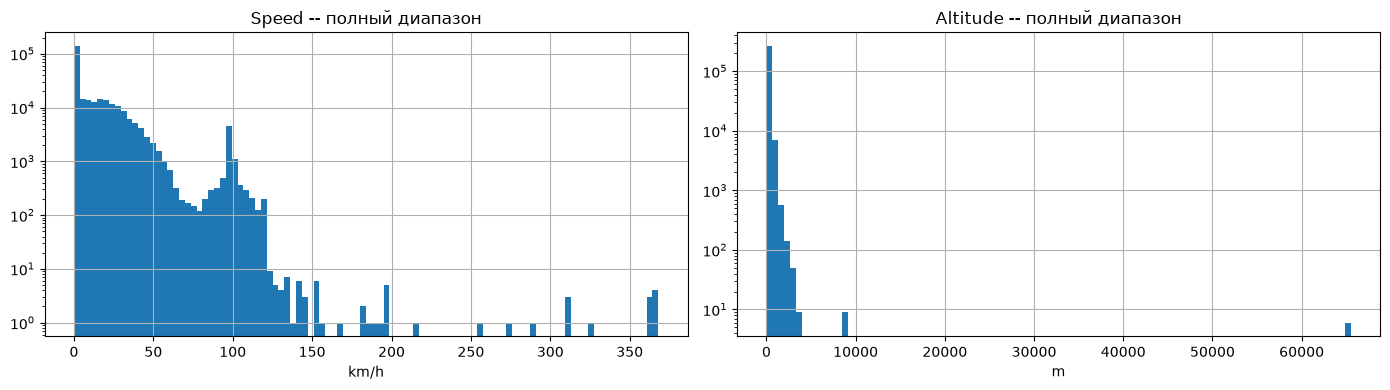

In [23]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(14, 4))

eda_axes[0].hist(eda_traffic.speed.dropna(), bins=100)
eda_axes[0].set_yscale('log')
eda_axes[0].set_title('Speed -- полный диапазон')
eda_axes[0].set_xlabel('km/h')

eda_axes[1].hist(eda_traffic.alt.dropna(), bins=100)
eda_axes[1].set_yscale('log')
eda_axes[1].set_title('Altitude -- полный диапазон')
eda_axes[1].set_xlabel('m')

plt.tight_layout()

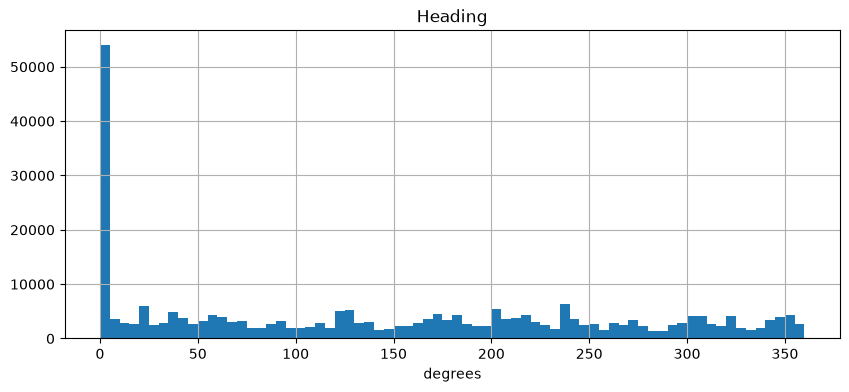

In [24]:
plt.figure(figsize=(10, 4))
plt.hist(eda_traffic.heading.dropna(), bins=72)
plt.title('Heading')
plt.xlabel('degrees')
plt.show()

In [25]:
eda_physical_flags = pd.DataFrame({
    'count': [
        (eda_traffic.speed > 120).sum(),
        (eda_traffic.speed > 200).sum(),
        (eda_traffic.alt > 1000).sum(),
        (~eda_traffic.heading.between(0, 360) & eda_traffic.heading.notna()).sum(),
    ]
}, index=[
    'speed > 120 km/h',
    'speed > 200 km/h',
    'alt > 1000 m',
    'heading outside [0, 360]',
])
eda_physical_flags['share'] = eda_physical_flags['count'] / len(eda_traffic)
eda_physical_flags

,count,share
speed > 120 km/h,70,0.000
speed > 200 km/h,15,0.000
alt > 1000 m,1625,0.006
"heading outside [0, 360]",0,0.000


У `speed` и особенно `alt` есть тяжелые хвосты: максимум скорости -- 368 км/ч, высоты -- 65 505 м. Таких точек мало, но для агрегатов они опасны. В следующем ноутбуке разумно сравнить clipping, robust-статистики и нелинейные преобразования, а исходные значения не удалять без проверки.

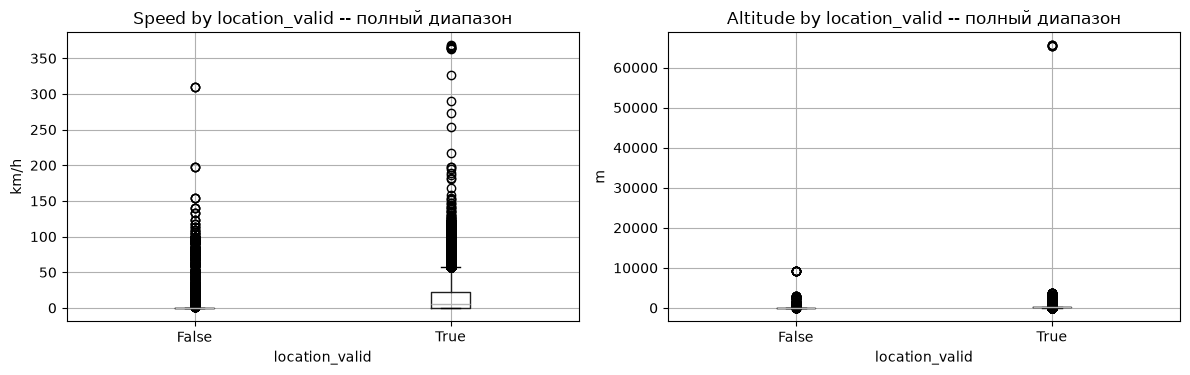

In [26]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(12, 4))

eda_traffic.boxplot(column='speed', by='location_valid', showfliers=True, ax=eda_axes[0])
eda_axes[0].set_title('Speed by location_valid -- полный диапазон')
eda_axes[0].set_xlabel('location_valid')
eda_axes[0].set_ylabel('km/h')

eda_traffic.boxplot(column='alt', by='location_valid', showfliers=True, ax=eda_axes[1])
eda_axes[1].set_title('Altitude by location_valid -- полный диапазон')
eda_axes[1].set_xlabel('location_valid')
eda_axes[1].set_ylabel('m')

plt.suptitle('')
plt.tight_layout()

### Попарные корреляции телеметрии

In [27]:
def eda_plot_corr(df, cols, method, title):
    corr = df[cols].corr(method=method)
    eda_fig, eda_ax = plt.subplots(figsize=(8, 6))
    im = eda_ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    eda_ax.set_xticks(range(len(cols)), cols, rotation=45, ha='right')
    eda_ax.set_yticks(range(len(cols)), cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            eda_ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

    eda_ax.set_title(title)
    eda_fig.colorbar(im, ax=eda_ax, fraction=.046, pad=.04)
    plt.tight_layout()
    plt.show()
    return corr

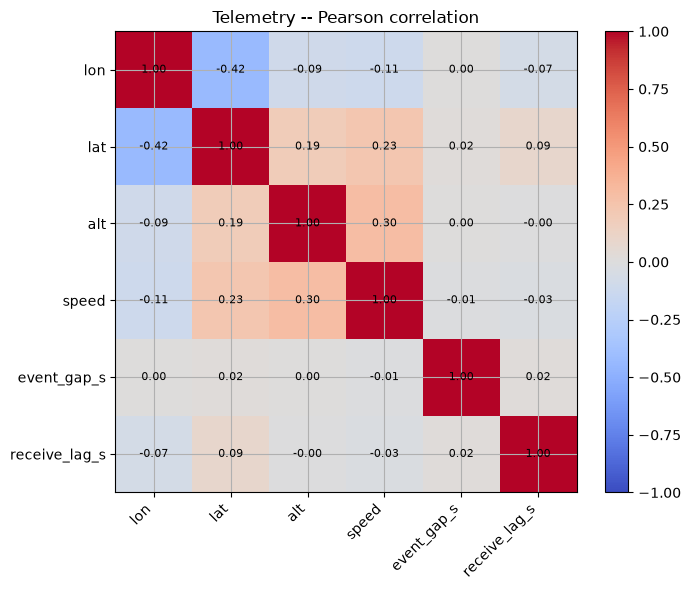

,lon,lat,alt,speed,event_gap_s,receive_lag_s
lon,1.000,-0.423,-0.095,-0.114,0.004,-0.069
lat,-0.423,1.000,0.186,0.230,0.018,0.093
alt,-0.095,0.186,1.000,0.296,0.003,-0.000
speed,-0.114,0.230,0.296,1.000,-0.011,-0.026
event_gap_s,0.004,0.018,0.003,-0.011,1.000,0.021
receive_lag_s,-0.069,0.093,-0.000,-0.026,0.021,1.000


In [28]:
eda_telemetry_corr_cols = ['lon', 'lat', 'alt', 'speed', 'event_gap_s', 'receive_lag_s']
eda_telemetry_corr = eda_traffic_time.loc[eda_traffic_time.location_valid, eda_telemetry_corr_cols]
eda_plot_corr(eda_telemetry_corr, eda_telemetry_corr_cols, 'pearson', 'Telemetry -- Pearson correlation')

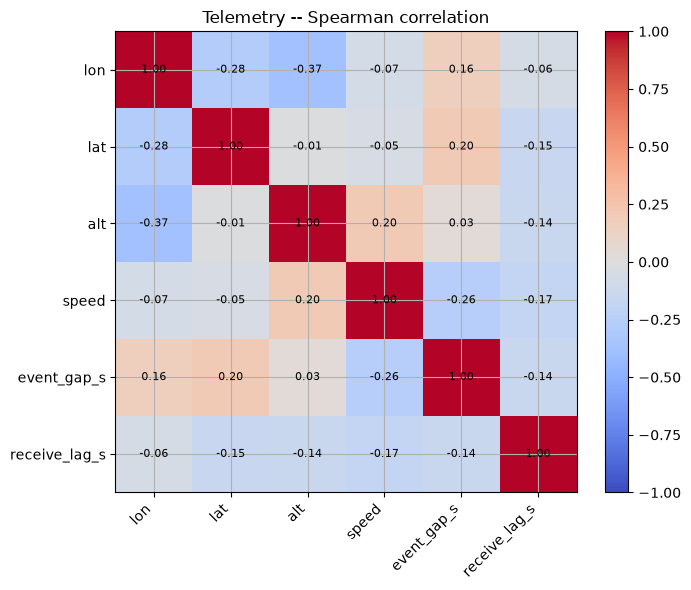

,lon,lat,alt,speed,event_gap_s,receive_lag_s
lon,1.000,-0.277,-0.367,-0.066,0.161,-0.056
lat,-0.277,1.000,-0.011,-0.050,0.202,-0.145
alt,-0.367,-0.011,1.000,0.198,0.033,-0.139
speed,-0.066,-0.050,0.198,1.000,-0.260,-0.174
event_gap_s,0.161,0.202,0.033,-0.260,1.000,-0.139
receive_lag_s,-0.056,-0.145,-0.139,-0.174,-0.139,1.000


In [29]:
eda_plot_corr(eda_telemetry_corr, eda_telemetry_corr_cols, 'spearman', 'Telemetry -- Spearman correlation')

Сильных универсальных линейных зависимостей между динамическими полями нет. Pearson и Spearman заметно различаются для некоторых пар -- еще один признак выбросов и нелинейности. `heading` в матрицу не включаю: это циклическая величина, где 1 и 359 градусов физически близки, поэтому обычная корреляция вводит в заблуждение.

## 7. Расписание

In [30]:
coords = eda_schedule.geom.str.extract(r'POINT \(([-\d.]+) ([-\d.]+)\)').astype(float)
eda_schedule['stop_lon'] = coords[0]
eda_schedule['stop_lat'] = coords[1]
eda_schedule['delay_s'] = (eda_schedule.time_fact_begin - eda_schedule.time_begin).dt.total_seconds()

pd.DataFrame({
    'value': [
        eda_schedule.tt_action_item_id.nunique(),
        eda_schedule.tr_id.nunique(),
        eda_schedule.geom.nunique(),
        eda_schedule.manual_fill.mean(),
        eda_schedule.building_address.isna().mean(),
    ]
}, index=[
    'schedule rows',
    'vehicles',
    'unique stop geometries',
    'manual_fill share',
    'missing address share'
])


,value
schedule rows,"16,674.000"
vehicles,39.000
unique stop geometries,847.000
manual_fill share,0.178
missing address share,0.175


В расписании 16 674 строки и 847 уникальных координат остановок -- одна и та же физическая остановка встречается много раз для разных ТС и моментов времени. `manual_fill=True` примерно у 17.8% строк.

In [31]:
eda_schedule.delay_s.describe(percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .995, .999])

count   16,674.000
mean        52.390
std        133.264
min       -404.000
0.1%      -330.327
1%        -216.000
5%        -137.000
25%        -20.750
50%         25.000
75%        112.000
95%        319.000
99%        449.000
99.5%      505.635
99.9%      594.289
max        685.000
Name: delay_s, dtype: float64

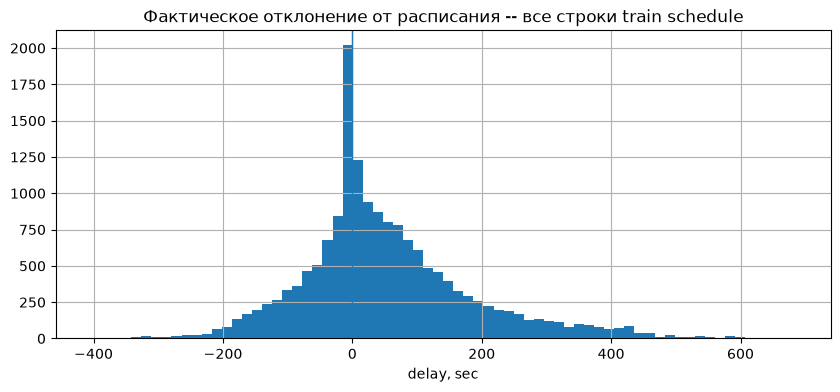

In [32]:
plt.figure(figsize=(10, 4))
plt.hist(eda_schedule.delay_s, bins=70)
plt.axvline(0, linewidth=1)
plt.title('Фактическое отклонение от расписания -- все строки train schedule')
plt.xlabel('delay, sec')
plt.show()


По всем строкам расписания медианное отклонение -- 25 секунд, p95 -- 319 секунд, p99 -- 449 секунд. `delay_s` здесь использую только для EDA: во время реального прогноза `time_fact_begin` еще неизвестно.

In [33]:
eda_schedule.groupby('manual_fill').delay_s.agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
manual_fill,,,,
False,13704,60.039,48.000,139.225
True,2970,17.098,0.000,93.552


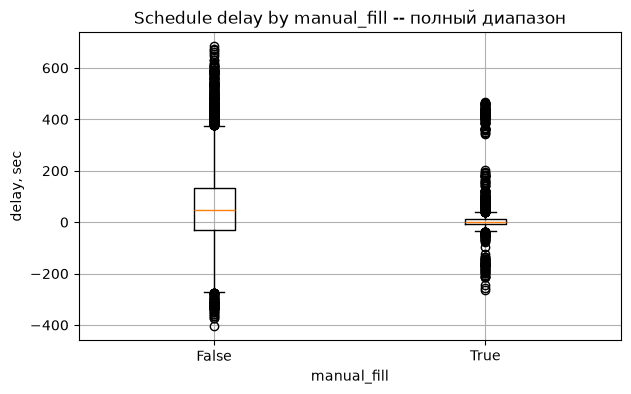

In [34]:
eda_fig, eda_ax = plt.subplots(figsize=(7, 4))
values = [
    eda_schedule.loc[~eda_schedule.manual_fill, 'delay_s'],
    eda_schedule.loc[eda_schedule.manual_fill, 'delay_s']
]
eda_ax.boxplot(values, tick_labels=['False', 'True'], showfliers=True)
eda_ax.set_title('Schedule delay by manual_fill -- полный диапазон')
eda_ax.set_xlabel('manual_fill')
eda_ax.set_ylabel('delay, sec')
plt.show()

У вручную заполненных приездов распределение отличается: медиана около 0 секунд против 48 секунд у остальных. `manual_fill` может быть полезным признаком расписания, но его эффект нужно проверять на test, а не воспринимать как причинный.

In [35]:
eda_schedule_time = eda_schedule.sort_values(['tr_id', 'time_begin']).copy()
eda_schedule_time['planned_gap_min'] = eda_schedule_time.groupby('tr_id').time_begin.diff().dt.total_seconds() / 60
eda_schedule_time['next_planned_gap_min'] = (
    eda_schedule_time.groupby('tr_id').time_begin.shift(-1) - eda_schedule_time.time_begin
).dt.total_seconds() / 60
eda_schedule_time.planned_gap_min.describe(percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .995, .999])

count   16,635.000
mean         2.106
std          7.494
min          0.000
0.1%         0.000
1%           0.000
5%           1.000
25%          1.000
50%          1.000
75%          2.000
95%          3.000
99%         15.000
99.5%       41.830
99.9%      106.000
max        249.000
Name: planned_gap_min, dtype: float64

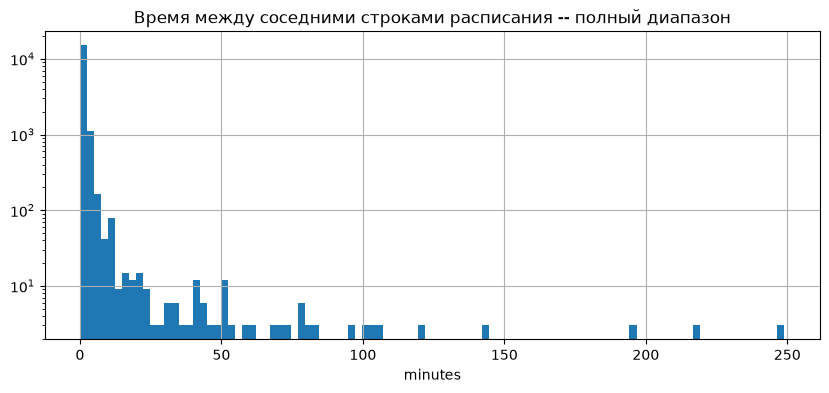

In [36]:
plt.figure(figsize=(10, 4))
plt.hist(eda_schedule_time.planned_gap_min.dropna(), bins=100)
plt.yscale('log')
plt.title('Время между соседними строками расписания -- полный диапазон')
plt.xlabel('minutes')
plt.show()


Медианный интервал между соседними строками расписания -- 1 минута, p95 -- 3 минуты, но есть разрывы до 249 минут. Такие разрывы, скорее всего, разделяют разные рейсы или блоки движения, поэтому в feature engineering их нужно учитывать отдельно.

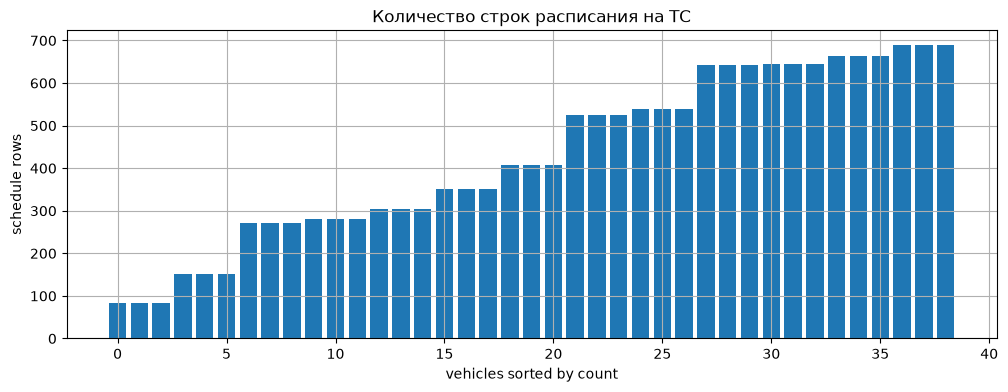

In [37]:
eda_visits_per_vehicle = eda_schedule.groupby('tr_id').size().sort_values()

plt.figure(figsize=(12, 4))
plt.bar(range(len(eda_visits_per_vehicle)), eda_visits_per_vehicle.values)
plt.title('Количество строк расписания на ТС')
plt.xlabel('vehicles sorted by count')
plt.ylabel('schedule rows')
plt.show()


## 8. Target и горизонт прогноза

In [38]:
eda_labels['horizon_min'] = (eda_labels.target_time_begin - eda_labels['T']).dt.total_seconds() / 60
eda_labels.horizon_min.describe(percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .995, .999])

count   4,434.000
mean       11.218
std         0.948
min        10.052
0.1%       10.052
1%         10.081
5%         10.114
25%        10.544
50%        11.000
75%        11.715
95%        13.062
99%        14.878
99.5%      15.000
99.9%      15.000
max        15.000
Name: horizon_min, dtype: float64

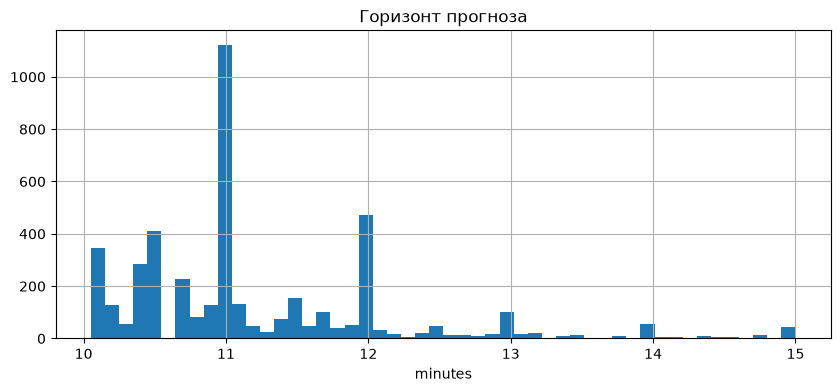

In [39]:
plt.figure(figsize=(10, 4))
plt.hist(eda_labels.horizon_min, bins=50)
plt.title('Горизонт прогноза')
plt.xlabel('minutes')
plt.show()

Фактический горизонт не равен фиксированным 10 или 15 минутам: медиана -- 11 минут, максимум -- ровно 15. Сам `horizon_min` можно использовать как feature, потому что он известен в момент прогноза.

In [40]:
eda_labels.target_delay_s.describe(percentiles=[.001, .01, .05, .1, .25, .5, .75, .9, .95, .99, .995, .999])

count   4,434.000
mean       48.890
std       131.224
min      -372.000
0.1%     -336.000
1%       -230.670
5%       -137.350
10%       -88.000
25%       -25.000
50%        24.000
75%       107.000
90%       223.700
95%       309.000
99%       448.340
99.5%     496.670
99.9%     588.701
max       672.000
Name: target_delay_s, dtype: float64

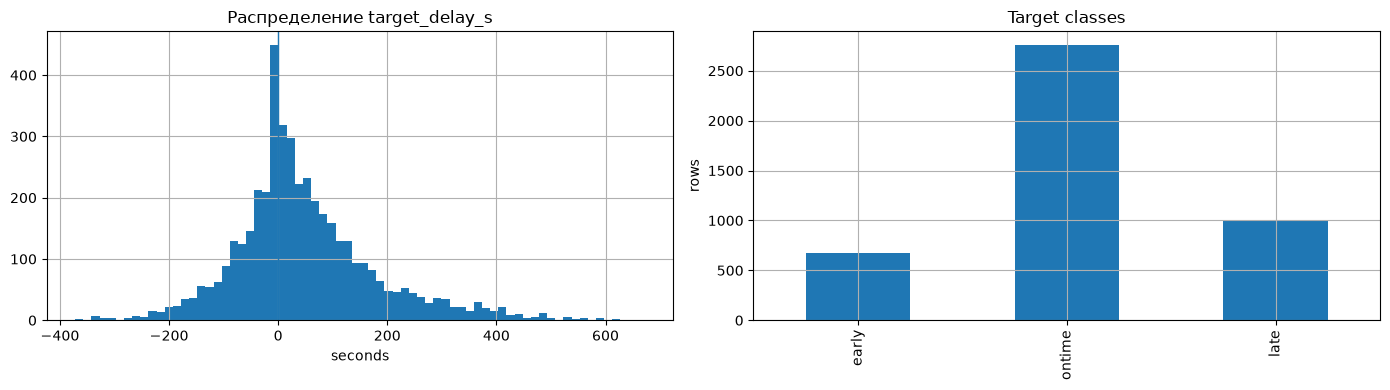

In [41]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(14, 4))

eda_axes[0].hist(eda_labels.target_delay_s, bins=70)
eda_axes[0].axvline(0, linewidth=1)
eda_axes[0].set_title('Распределение target_delay_s')
eda_axes[0].set_xlabel('seconds')

eda_order = ['early', 'ontime', 'late']
eda_labels.target_class.value_counts().reindex(eda_order).plot.bar(ax=eda_axes[1])
eda_axes[1].set_title('Target classes')
eda_axes[1].set_xlabel('')
eda_axes[1].set_ylabel('rows')

plt.tight_layout()

In [42]:
eda_labels.target_class.value_counts().reindex(['early', 'ontime', 'late']).to_frame('count').assign(
    share=lambda x: x['count'] / len(eda_labels)
)

,count,share
target_class,,
early,679,0.153
ontime,2757,0.622
late,998,0.225


Target сдвинут в положительную сторону: медиана 24 секунды, среднее около 49 секунд. При этом распределение достаточно широкое -- от `-372` до `672` секунд. Класс `ontime` занимает 62.2%, `late` -- 22.5%, `early` -- 15.3%.

## 9. `cur_dev_s` как baseline

In [43]:
eda_residual = eda_labels.target_delay_s - eda_labels.cur_dev_s

pd.Series({
    'MAE: prediction = 0': eda_labels.target_delay_s.abs().mean(),
    'MAE: prediction = cur_dev_s': eda_residual.abs().mean(),
    'corr(target, cur_dev_s)': eda_labels[['target_delay_s', 'cur_dev_s']].corr().iloc[0, 1],
    'median(target - cur_dev_s)': eda_residual.median(),
})

MAE: prediction = 0           97.168
MAE: prediction = cur_dev_s   93.032
corr(target, cur_dev_s)        0.511
median(target - cur_dev_s)     0.000
dtype: float64

In [44]:
eda_residual.describe(percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .995, .999])

count   4,434.000
mean       -5.863
std       130.225
min      -661.000
0.1%     -627.742
1%       -378.340
5%       -209.350
25%       -78.000
50%         0.000
75%        63.000
95%       197.000
99%       339.000
99.5%     394.175
99.9%     621.783
max       774.000
dtype: float64

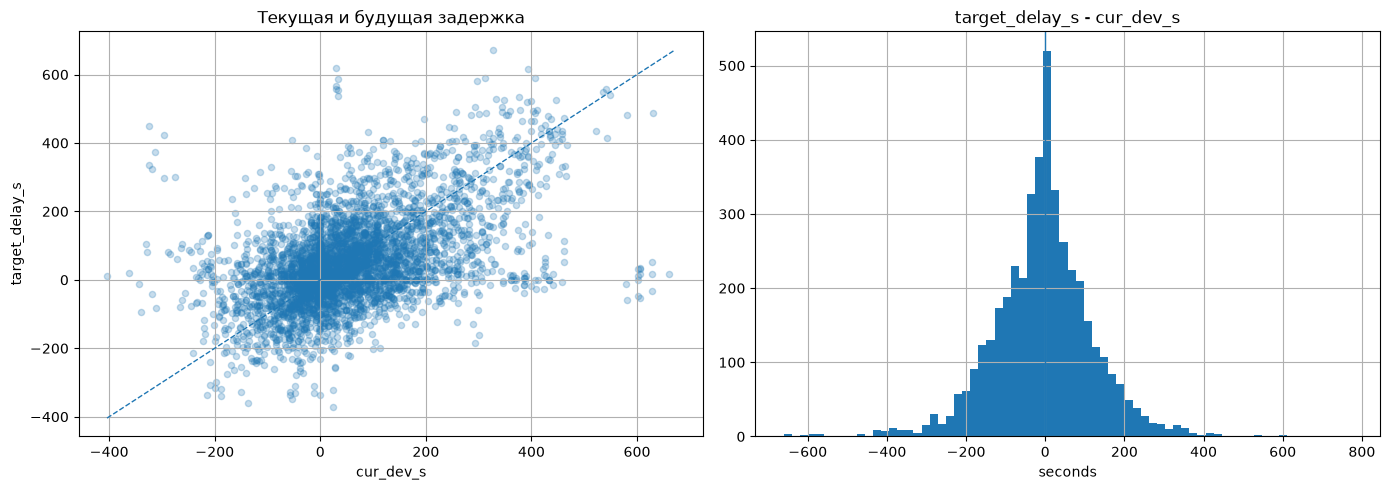

In [45]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(14, 5))

eda_axes[0].scatter(eda_labels.cur_dev_s, eda_labels.target_delay_s, alpha=.25, s=20)
lims = [
    min(eda_labels.cur_dev_s.min(), eda_labels.target_delay_s.min()),
    max(eda_labels.cur_dev_s.max(), eda_labels.target_delay_s.max())
]
eda_axes[0].plot(lims, lims, '--', linewidth=1)
eda_axes[0].set_title('Текущая и будущая задержка')
eda_axes[0].set_xlabel('cur_dev_s')
eda_axes[0].set_ylabel('target_delay_s')

eda_axes[1].hist(eda_residual, bins=70)
eda_axes[1].axvline(0, linewidth=1)
eda_axes[1].set_title('target_delay_s - cur_dev_s')
eda_axes[1].set_xlabel('seconds')

plt.tight_layout()

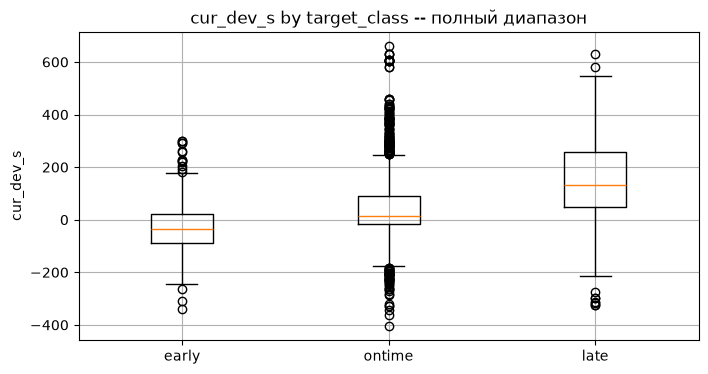

In [46]:
eda_fig, eda_ax = plt.subplots(figsize=(8, 4))
eda_order = ['early', 'ontime', 'late']
values = [eda_labels.loc[eda_labels.target_class == cls, 'cur_dev_s'] for cls in eda_order]
eda_ax.boxplot(values, tick_labels=eda_order, showfliers=True)
eda_ax.set_title('cur_dev_s by target_class -- полный диапазон')
eda_ax.set_ylabel('cur_dev_s')
plt.show()

`cur_dev_s` -- самый очевидный anchor: Pearson correlation с target около 0.51. Но baseline `prediction = cur_dev_s` дает MAE около 93 секунд против 97 секунд у нулевого прогноза. Residual имеет медиану 0, но остается очень широким -- одной инерции задержки недостаточно.

## 10. Состояние ТС в момент прогноза

Чтобы посмотреть связи target с физическим состоянием, беру последнюю **валидную** GPS-точку, которая уже доступна к `T`. Для этого использую `available_time = max(event_time, receive_time)`. Это EDA-представление, а полноценные оконные признаки построю отдельно в feature engineering.

In [47]:
eda_telemetry_available = eda_traffic.copy()
eda_telemetry_available['available_time'] = eda_telemetry_available[['event_time', 'receive_time']].max(axis=1).astype('datetime64[ns]')
eda_labels['T'] = eda_labels['T'].astype('datetime64[ns]')

eda_valid_telemetry = eda_telemetry_available.loc[
    eda_telemetry_available.location_valid & eda_telemetry_available.lon.notna() & eda_telemetry_available.lat.notna()
].sort_values('available_time')

eda_point_state = pd.merge_asof(
    eda_labels.sort_values('T'),
    eda_valid_telemetry,
    left_on='T',
    right_on='available_time',
    by='tr_id',
    direction='backward',
    suffixes=('', '_telemetry')
)

In [48]:
eda_target_geom = eda_schedule_time[[
    'tt_action_item_id', 'stop_lon', 'stop_lat', 'manual_fill',
    'planned_gap_min', 'next_planned_gap_min'
]].rename(columns={'tt_action_item_id': 'target_stop_id'})

eda_point_state = eda_point_state.merge(eda_target_geom, on='target_stop_id', how='left')
eda_point_state['valid_age_s'] = (
    eda_point_state['T'] - eda_point_state.available_time
).dt.total_seconds()
eda_point_state['receive_lag_s'] = (
    eda_point_state.receive_time - eda_point_state.event_time
).dt.total_seconds()

r = 6_371_000
lat1 = np.radians(eda_point_state.lat)
lat2 = np.radians(eda_point_state.stop_lat)
dlat = lat2 - lat1
dlon = np.radians(eda_point_state.stop_lon - eda_point_state.lon)
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
eda_point_state['distance_to_target_m'] = 2 * r * np.arcsin(np.sqrt(a))


In [49]:
eda_point_state[[
    'target_delay_s', 'cur_dev_s', 'horizon_min', 'speed',
    'valid_age_s', 'distance_to_target_m', 'receive_lag_s'
]].describe(percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .995, .999]).T

,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.5%,99.9%,max
target_delay_s,"4,434.000",48.890,131.224,-372.000,-336.000,-230.670,-137.350,-25.000,24.000,107.000,309.000,448.340,496.670,588.701,672.000
cur_dev_s,"4,434.000",54.753,132.093,-404.000,-329.567,-219.670,-128.350,-19.000,26.000,115.000,314.350,436.000,465.505,619.041,661.000
horizon_min,"4,434.000",11.218,0.948,10.052,10.052,10.081,10.114,10.544,11.000,11.715,13.062,14.878,15.000,15.000,15.000
speed,"4,433.000",16.282,21.189,0.000,0.000,0.000,0.000,0.000,9.100,25.300,56.700,101.000,107.184,115.282,121.000
valid_age_s,"4,433.000",149.246,633.324,0.000,0.008,0.082,0.440,2.601,6.183,11.875,"1,036.895","3,352.254","4,252.414","6,008.667","11,449.633"
distance_to_target_m,"4,433.000","2,994.582","3,912.033",3.356,10.252,30.289,141.236,"1,083.656","1,988.540","3,319.436","8,356.301","21,341.421","22,071.318","31,621.984","33,147.282"
receive_lag_s,"4,433.000",1.323,4.184,-17.527,-17.141,-17.136,0.471,1.042,1.604,2.199,3.740,6.051,8.326,32.548,105.196


Для 4 433 из 4 434 точек находится предыдущая валидная позиция. Медианный возраст этой позиции всего около 6 секунд, но p95 уже около 17 минут -- редкие длинные разрывы действительно важны. Медианное прямое расстояние до target около 2 км.

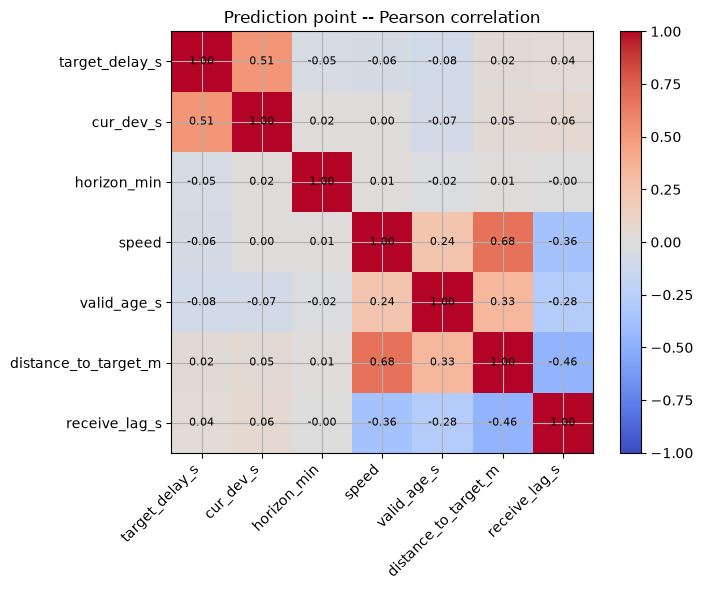

,target_delay_s,cur_dev_s,horizon_min,speed,valid_age_s,distance_to_target_m,receive_lag_s
target_delay_s,1.000,0.511,-0.051,-0.059,-0.082,0.024,0.035
cur_dev_s,0.511,1.000,0.021,0.002,-0.071,0.053,0.062
horizon_min,-0.051,0.021,1.000,0.012,-0.022,0.014,-0.005
speed,-0.059,0.002,0.012,1.000,0.240,0.675,-0.363
valid_age_s,-0.082,-0.071,-0.022,0.240,1.000,0.331,-0.277
distance_to_target_m,0.024,0.053,0.014,0.675,0.331,1.000,-0.464
receive_lag_s,0.035,0.062,-0.005,-0.363,-0.277,-0.464,1.000


In [50]:
eda_point_corr_cols = [
    'target_delay_s', 'cur_dev_s', 'horizon_min', 'speed',
    'valid_age_s', 'distance_to_target_m', 'receive_lag_s'
]
eda_plot_corr(eda_point_state, eda_point_corr_cols, 'pearson', 'Prediction point -- Pearson correlation')

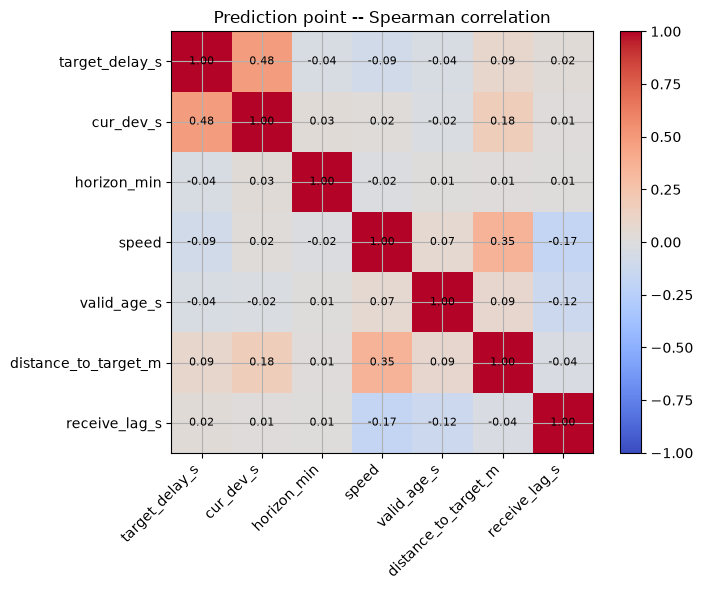

,target_delay_s,cur_dev_s,horizon_min,speed,valid_age_s,distance_to_target_m,receive_lag_s
target_delay_s,1.000,0.479,-0.044,-0.088,-0.040,0.087,0.024
cur_dev_s,0.479,1.000,0.026,0.017,-0.024,0.175,0.015
horizon_min,-0.044,0.026,1.000,-0.017,0.007,0.010,0.007
speed,-0.088,0.017,-0.017,1.000,0.068,0.353,-0.173
valid_age_s,-0.040,-0.024,0.007,0.068,1.000,0.086,-0.123
distance_to_target_m,0.087,0.175,0.010,0.353,0.086,1.000,-0.038
receive_lag_s,0.024,0.015,0.007,-0.173,-0.123,-0.038,1.000


In [51]:
eda_plot_corr(eda_point_state, eda_point_corr_cols, 'spearman', 'Prediction point -- Spearman correlation')

На уровне одной последней точки явно доминирует `cur_dev_s`. Простые `speed`, расстояние и свежесть сами по себе с target коррелируют слабо. Это ожидаемо: физический эффект скорее лежит в динамике -- тренде скорости, движении к target, остановках, плотности пакетов и изменении расстояния на окне перед `T`.

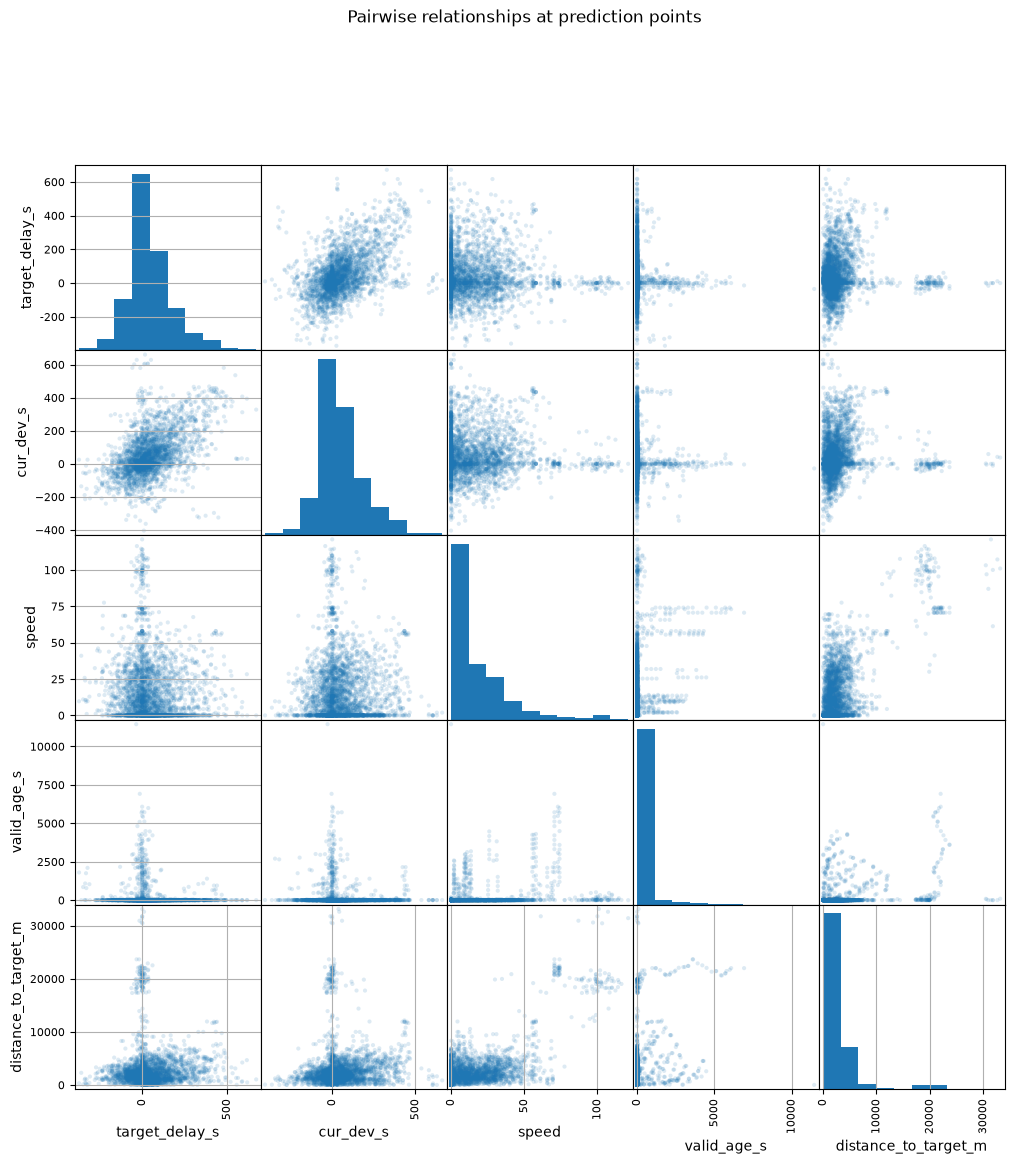

In [52]:
eda_scatter_cols = ['target_delay_s', 'cur_dev_s', 'speed', 'valid_age_s', 'distance_to_target_m']
eda_scatter_sample = eda_point_state[eda_scatter_cols].dropna().sample(
    min(3000, eda_point_state[eda_scatter_cols].dropna().shape[0]),
    random_state=EDA_SEED
)

pd.plotting.scatter_matrix(
    eda_scatter_sample,
    figsize=(12, 12),
    alpha=.15,
    diagonal='hist'
)
plt.suptitle('Pairwise relationships at prediction points', y=1.01)
plt.show()

## PCA базовых признаков прогнозной точки

PCA использую здесь только как диагностику структуры признаков. Перед PCA заполняю пропуски медианами и стандартизую признаки. Target в PCA не входит.

Для циклических величин использую `sin/cos`: сырой `heading=359` близок к `0`, хотя численно они далеко.

In [53]:
eda_point_state['heading_sin'] = np.sin(np.radians(eda_point_state.heading))
eda_point_state['heading_cos'] = np.cos(np.radians(eda_point_state.heading))
eda_point_state['hour_sin'] = np.sin(2 * np.pi * eda_point_state['T'].dt.hour / 24)
eda_point_state['hour_cos'] = np.cos(2 * np.pi * eda_point_state['T'].dt.hour / 24)

eda_pca_cols = [
    'cur_dev_s', 'horizon_min', 'lon', 'lat', 'alt', 'speed',
    'heading_sin', 'heading_cos', 'valid_age_s', 'receive_lag_s',
    'distance_to_target_m', 'stop_lon', 'stop_lat',
    'planned_gap_min', 'next_planned_gap_min', 'manual_fill',
    'hour_sin', 'hour_cos'
]

eda_pca_frame = eda_point_state[eda_pca_cols].copy()
eda_pca_frame['manual_fill'] = eda_pca_frame.manual_fill.astype(float)

eda_pca_imputer = SimpleImputer(strategy='median')
eda_pca_scaler = StandardScaler()
eda_pca = PCA(random_state=EDA_SEED)

eda_pca_values = eda_pca_imputer.fit_transform(eda_pca_frame)
eda_pca_scaled = eda_pca_scaler.fit_transform(eda_pca_values)
eda_pca_scores = eda_pca.fit_transform(eda_pca_scaled)


In [54]:
eda_pca_variance = pd.DataFrame({
    'explained_variance': eda_pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(eda_pca.explained_variance_ratio_)
}, index=[f'PC{i}' for i in range(1, len(eda_pca_cols) + 1)])

eda_pca_variance


,explained_variance,cumulative_variance
PC1,0.197,0.197
PC2,0.109,0.306
PC3,0.080,0.386
PC4,0.067,0.453
PC5,0.064,0.517
PC6,0.058,0.575
PC7,0.057,0.632
PC8,0.054,0.686
PC9,0.052,0.738
PC10,0.051,0.789


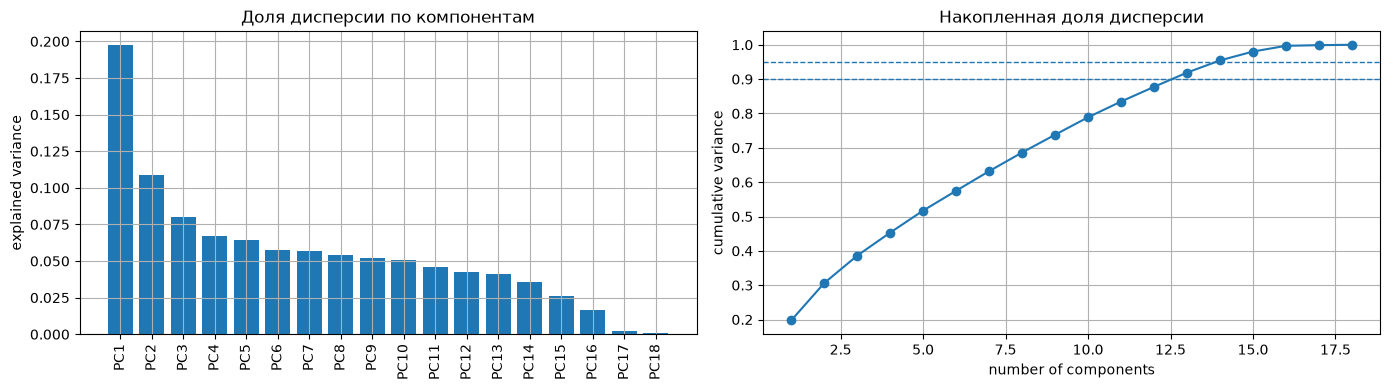

In [55]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(14, 4))

eda_axes[0].bar(eda_pca_variance.index, eda_pca_variance.explained_variance)
eda_axes[0].set_title('Доля дисперсии по компонентам')
eda_axes[0].set_ylabel('explained variance')
eda_axes[0].tick_params(axis='x', rotation=90)

eda_axes[1].plot(
    range(1, len(eda_pca_variance) + 1),
    eda_pca_variance.cumulative_variance,
    marker='o'
)
eda_axes[1].axhline(.90, linestyle='--', linewidth=1)
eda_axes[1].axhline(.95, linestyle='--', linewidth=1)
eda_axes[1].set_title('Накопленная доля дисперсии')
eda_axes[1].set_xlabel('number of components')
eda_axes[1].set_ylabel('cumulative variance')

plt.tight_layout()


In [56]:
eda_pc_names = eda_pca_variance.index.tolist()
eda_pca_corr = pd.DataFrame(
    np.corrcoef(np.c_[eda_pca_scaled, eda_pca_scores].T)[
        :len(eda_pca_cols), len(eda_pca_cols):
    ],
    index=eda_pca_cols,
    columns=eda_pc_names
)

eda_pca_corr


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
cur_dev_s,0.010,-0.354,-0.304,0.264,-0.027,0.192,0.156,0.464,-0.075,0.464,-0.200,-0.329,0.108,0.232,0.008,-0.022,0.010,-0.000
horizon_min,0.083,-0.136,0.412,0.384,0.444,0.103,-0.107,0.167,0.077,0.029,-0.329,0.516,-0.090,0.144,-0.016,0.001,-0.000,-0.000
lon,-0.479,0.815,0.145,-0.038,-0.012,0.105,0.050,0.189,-0.014,0.137,-0.050,-0.005,-0.002,-0.050,0.015,0.015,0.024,0.097
lat,0.799,0.045,0.489,-0.150,-0.156,0.078,0.088,-0.035,-0.091,0.122,0.002,-0.061,-0.007,0.010,-0.079,0.081,0.134,-0.017
alt,0.238,0.070,-0.047,-0.189,0.232,-0.352,-0.431,0.366,-0.459,0.115,0.352,0.135,0.178,0.074,-0.021,-0.017,-0.001,-0.001
speed,0.689,0.206,-0.219,-0.061,0.099,-0.129,-0.027,0.160,0.152,-0.010,-0.278,-0.029,0.036,-0.359,-0.216,-0.316,0.002,-0.002
heading_sin,-0.001,0.033,0.080,0.431,-0.466,-0.165,-0.221,0.112,-0.427,-0.437,-0.299,-0.140,-0.134,0.012,-0.026,0.012,0.000,0.007
heading_cos,-0.142,-0.126,0.260,0.216,-0.284,-0.223,-0.055,0.490,0.572,-0.140,0.352,-0.022,-0.066,-0.014,-0.026,-0.011,0.011,-0.003
valid_age_s,0.392,0.433,-0.253,0.344,0.093,0.147,0.054,-0.196,0.081,-0.209,0.241,-0.026,0.149,0.409,-0.324,-0.036,0.002,0.004
receive_lag_s,-0.552,-0.257,0.121,0.080,-0.194,0.049,0.111,-0.005,-0.062,-0.014,-0.056,0.177,0.630,-0.226,-0.248,0.087,0.003,-0.001


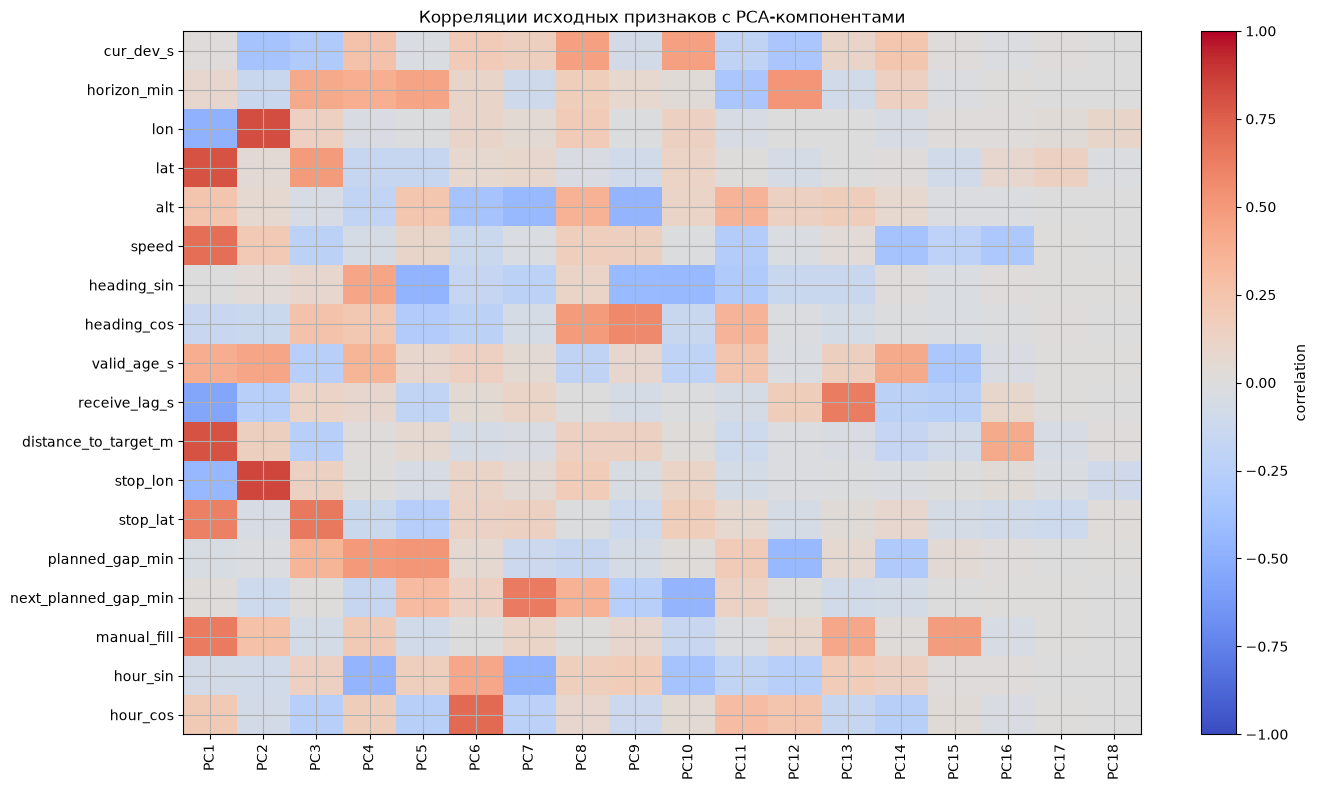

In [57]:
eda_fig, eda_ax = plt.subplots(figsize=(14, 8))
eda_pca_im = eda_ax.imshow(eda_pca_corr, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
eda_ax.set_xticks(range(len(eda_pc_names)))
eda_ax.set_xticklabels(eda_pc_names, rotation=90)
eda_ax.set_yticks(range(len(eda_pca_cols)))
eda_ax.set_yticklabels(eda_pca_cols)
plt.colorbar(eda_pca_im, ax=eda_ax, label='correlation')
plt.title('Корреляции исходных признаков с PCA-компонентами')
plt.tight_layout()


Первая компонента объясняет около 20% дисперсии, первые две -- около 31%. До 90% нужно 13 компонент, до 95% -- 14. Явного сжатия в 2--3 измерения здесь нет.

`PC1` в основном собирает географию, расстояние, скорость и `manual_fill`, `PC2` -- долготу текущей и целевой позиции. Следующие компоненты смешивают расписание, время суток, курс и свежесть телеметрии. Поэтому PCA имеет смысл оставить как дополнительное компактное представление, но исходные физические признаки удалять не стоит.

## Random Forest -- важность базовых признаков

RF использую как нелинейную диагностику. Это не оценка причинности и не финальный feature selection: impurity importance может предпочитать непрерывные признаки и признаки с большим числом возможных разбиений.

In [58]:
eda_rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=EDA_SEED,
    n_jobs=-1
)
eda_rf.fit(eda_pca_values, eda_point_state.target_delay_s)

eda_rf_importance = pd.Series(
    eda_rf.feature_importances_,
    index=eda_pca_cols,
    name='importance'
).sort_values(ascending=False)

eda_rf_importance.to_frame()


,importance
cur_dev_s,0.267
lat,0.097
lon,0.080
stop_lon,0.077
stop_lat,0.072
hour_sin,0.067
distance_to_target_m,0.065
hour_cos,0.046
alt,0.039
receive_lag_s,0.028


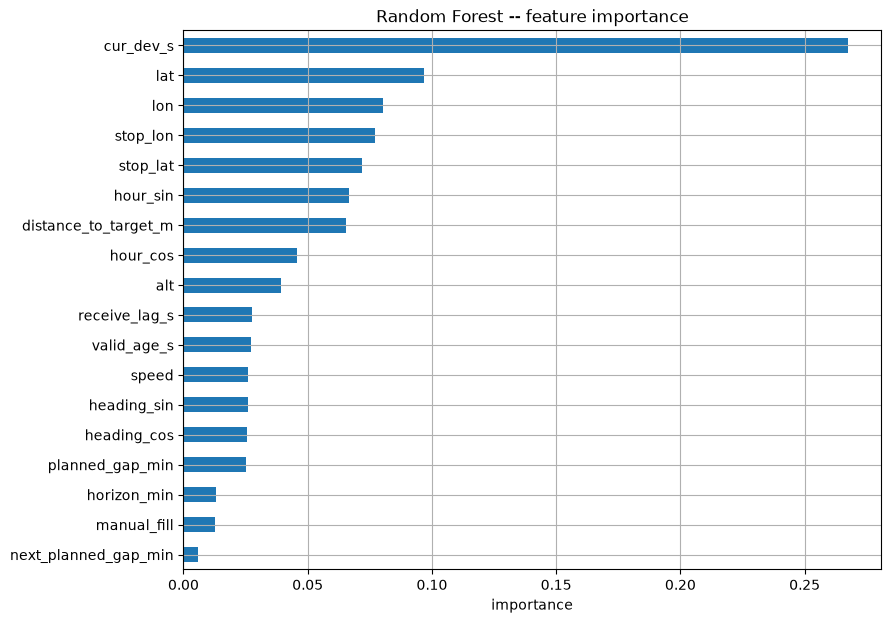

In [59]:
eda_rf_importance.sort_values().plot.barh(figsize=(9, 7))
plt.title('Random Forest -- feature importance')
plt.xlabel('importance')
plt.show()


`cur_dev_s` остается главным одиночным признаком. После него RF высоко ставит текущую и целевую географию, время суток и расстояние до target.

География здесь может кодировать конкретные участки маршрутов и особенности train, поэтому в feature engineering я не ограничусь сырыми координатами: добавлю расстояния, направление движения, локальные spatial bins и взаимодействия с текущей задержкой и временем. Важность `valid_age_s` и `receive_lag_s` дополнительно подтверждает, что качество и свежесть телеметрии стоит хранить отдельно.

## 11. Синтетическая часть train

In [60]:
eda_labels['is_synthetic'] = eda_labels.tr_id >= 9_000_000

pd.DataFrame({
    'rows': eda_labels.groupby('is_synthetic').size(),
    'share': eda_labels.groupby('is_synthetic').size() / len(eda_labels),
    'vehicles': eda_labels.groupby('is_synthetic').tr_id.nunique(),
    'target_mean': eda_labels.groupby('is_synthetic').target_delay_s.mean(),
    'target_std': eda_labels.groupby('is_synthetic').target_delay_s.std(),
}).rename(index={False: 'real', True: 'synthetic'})

,rows,share,vehicles,target_mean,target_std
is_synthetic,,,,,
real,1141,0.257,13,44.851,124.388
synthetic,3293,0.743,26,50.289,133.500


In [61]:
traffic_counts = eda_traffic.groupby('tr_id').size().rename('traffic_rows')
schedule_counts = eda_schedule.groupby('tr_id').size().rename('schedule_rows')
label_counts = eda_labels.groupby('tr_id').size().rename('label_rows')

eda_vehicle_stats = pd.concat([traffic_counts, schedule_counts, label_counts], axis=1).fillna(0).astype(int)
eda_vehicle_stats['labeled'] = eda_vehicle_stats.label_rows > 0
eda_vehicle_stats['synthetic'] = eda_vehicle_stats.index >= 9_000_000

pd.DataFrame({
    'count': [
        len(eda_vehicle_stats),
        eda_vehicle_stats.labeled.sum(),
        (~eda_vehicle_stats.labeled).sum(),
        (eda_vehicle_stats.labeled & ~eda_vehicle_stats.synthetic).sum(),
        (eda_vehicle_stats.labeled & eda_vehicle_stats.synthetic).sum(),
    ]
}, index=[
    'traffic vehicles',
    'labeled vehicles',
    'context-only vehicles',
    'real labeled vehicles',
    'synthetic labeled vehicles',
])

,count
traffic vehicles,56
labeled vehicles,39
context-only vehicles,17
real labeled vehicles,13
synthetic labeled vehicles,26


In [62]:
eda_real = eda_vehicle_stats.query('labeled and not synthetic').reset_index()
eda_synthetic = eda_vehicle_stats.query('labeled and synthetic').reset_index()

eda_synthetic_pairs = eda_synthetic.merge(
    eda_real,
    on=['traffic_rows', 'schedule_rows'],
    suffixes=('_synthetic', '_real')
)[[
    'tr_id_synthetic', 'tr_id_real', 'traffic_rows', 'schedule_rows',
    'label_rows_synthetic', 'label_rows_real'
]]

eda_synthetic_pairs.sort_values('tr_id_synthetic')

,tr_id_synthetic,tr_id_real,traffic_rows,schedule_rows,label_rows_synthetic,label_rows_real
0,9000000,122048,6117,664,203,145
1,9000001,122048,6117,664,203,145
2,9000002,122613,9574,280,85,53
3,9000003,122613,9574,280,87,53
4,9000004,122658,4260,272,102,71
5,9000005,122658,4260,272,103,71
6,9000006,129964,6193,540,157,125
7,9000007,129964,6193,540,156,125
8,9000008,130072,6846,152,40,27
9,9000009,130072,6846,152,41,27


Размеченная часть содержит 13 реальных и 26 синтетических ТС. Синтетика дает 74.3% всех train-labels. По числу строк телеметрии и расписания синтетические ТС группируются с реальными попарно -- это сильный признак родственных траекторий, поэтому случайный row-wise split может серьезно завысить качество.

Идентификатор `tr_id >= 9_000_000` использую здесь как наблюдаемое разделение именно этой раздачи, а не как общий контракт данных.

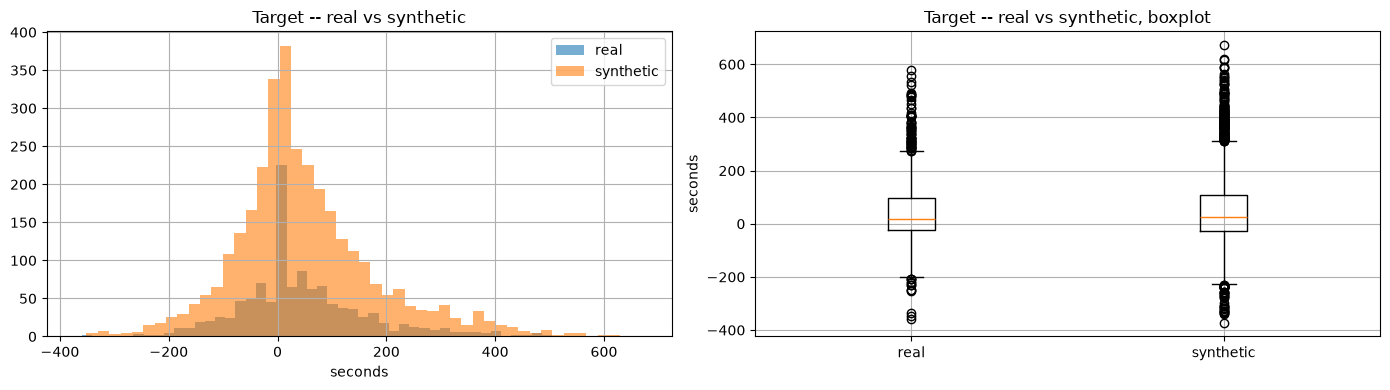

In [63]:
eda_fig, eda_axes = plt.subplots(1, 2, figsize=(14, 4))

eda_axes[0].hist(
    eda_labels.loc[~eda_labels.is_synthetic, 'target_delay_s'],
    bins=50,
    alpha=.6,
    label='real'
)
eda_axes[0].hist(
    eda_labels.loc[eda_labels.is_synthetic, 'target_delay_s'],
    bins=50,
    alpha=.6,
    label='synthetic'
)
eda_axes[0].set_title('Target -- real vs synthetic')
eda_axes[0].set_xlabel('seconds')
eda_axes[0].legend()

values = [
    eda_labels.loc[~eda_labels.is_synthetic, 'target_delay_s'],
    eda_labels.loc[eda_labels.is_synthetic, 'target_delay_s']
]
eda_axes[1].boxplot(values, tick_labels=['real', 'synthetic'], showfliers=True)
eda_axes[1].set_title('Target -- real vs synthetic, boxplot')
eda_axes[1].set_ylabel('seconds')

plt.tight_layout()

In [64]:
eda_class_share = pd.crosstab(
    eda_labels.is_synthetic.map({False: 'real', True: 'synthetic'}),
    eda_labels.target_class,
    normalize='index'
)[['early', 'ontime', 'late']]

eda_class_share

target_class,early,ontime,late
is_synthetic,,,
real,0.149,0.641,0.210
synthetic,0.155,0.615,0.230


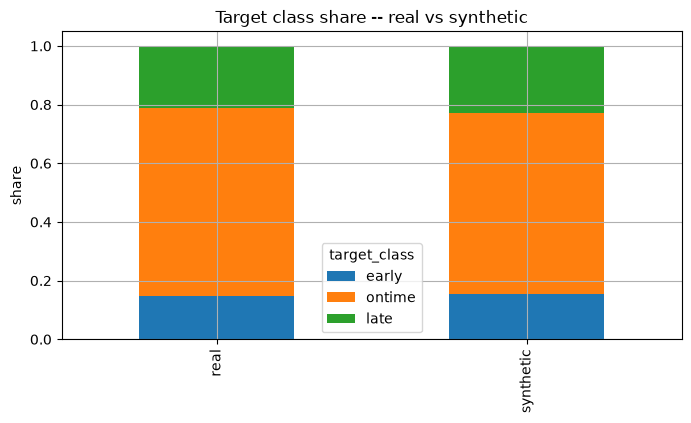

In [65]:
eda_class_share.plot.bar(stacked=True, figsize=(8, 4))
plt.title('Target class share -- real vs synthetic')
plt.xlabel('')
plt.ylabel('share')
plt.legend(title='target_class')
plt.show()

Средние и доли классов у real/synthetic близки, но этого недостаточно для независимости. В дальнейшем основной ориентир качества -- отдельный real test. Для внутренней CV train нужно группировать родственные ТС, а не перемешивать отдельные строки.

## 12. Пространственная структура

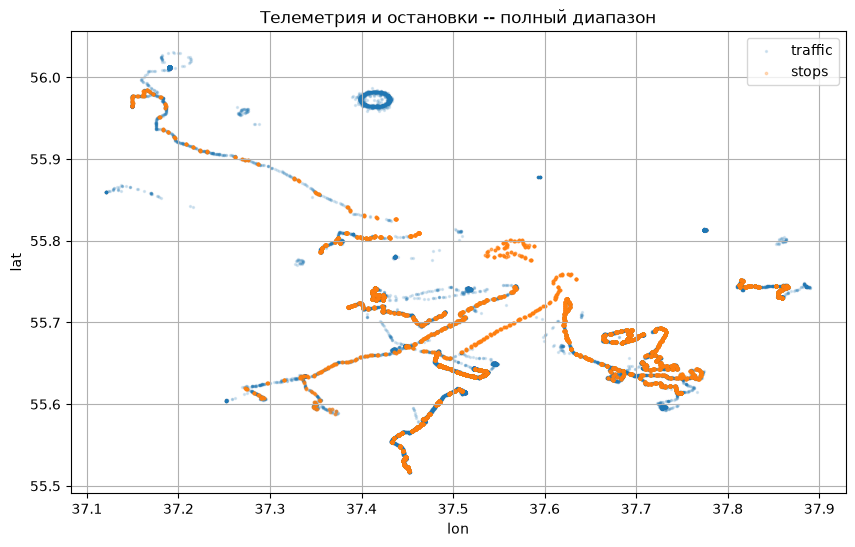

In [66]:
eda_valid_traffic = eda_traffic.loc[
    eda_traffic.location_valid & eda_traffic.lon.notna() & eda_traffic.lat.notna(),
    ['lon', 'lat']
]
eda_traffic_sample = eda_valid_traffic.sample(
    min(30_000, len(eda_valid_traffic)),
    random_state=EDA_SEED
)

plt.figure(figsize=(10, 6))
plt.scatter(eda_traffic_sample.lon, eda_traffic_sample.lat, s=2, alpha=.15, label='traffic')
plt.scatter(eda_schedule.stop_lon, eda_schedule.stop_lat, s=3, alpha=.25, label='stops')
plt.title('Телеметрия и остановки -- полный диапазон')
plt.xlabel('lon')
plt.ylabel('lat')
plt.legend()
plt.show()


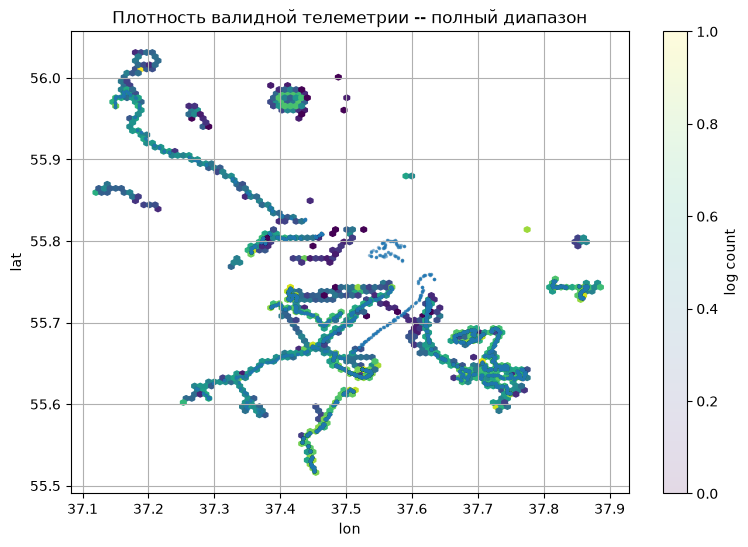

In [67]:
plt.figure(figsize=(9, 6))
plt.hexbin(eda_valid_traffic.lon, eda_valid_traffic.lat, gridsize=90, mincnt=1, bins='log')
plt.scatter(eda_schedule.stop_lon, eda_schedule.stop_lat, s=2, alpha=.15)
plt.title('Плотность валидной телеметрии -- полный диапазон')
plt.xlabel('lon')
plt.ylabel('lat')
plt.colorbar(label='log count')
plt.show()


Полный диапазон показывает географические выбросы, scatter и hexbin показывают общую географию и плотность движения. Сырые `lon/lat` сами по себе мало физичны: для модели полезнее расстояние и направление до target, пройденный путь, скорость сближения, локальная плотность ТС и признаки положения относительно последовательности остановок.

## 13. Зависимость target от времени

In [68]:
eda_labels['hour'] = eda_labels['T'].dt.hour

eda_hour_stats = eda_labels.groupby('hour').agg(
    samples=('sample_id', 'size'),
    target_mean=('target_delay_s', 'mean'),
    target_median=('target_delay_s', 'median'),
    target_mae=('target_delay_s', lambda x: x.abs().mean()),
)

eda_hour_stats

,samples,target_mean,target_median,target_mae
hour,,,,
0,11,42.273,11.000,46.091
2,100,17.820,3.000,52.640
3,203,63.640,40.000,85.877
4,222,79.324,65.500,104.712
5,183,47.546,37.000,86.552
6,226,14.655,3.500,67.761
7,270,91.356,60.000,128.296
8,228,56.943,53.000,89.417
9,223,13.910,19.000,76.224


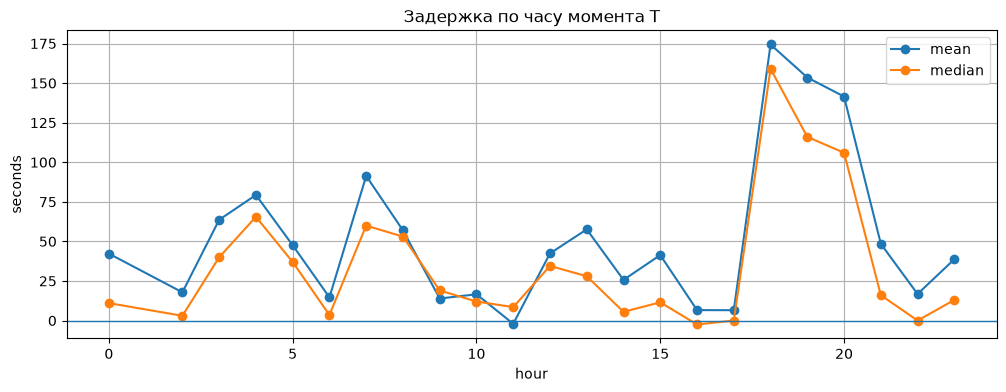

In [69]:
eda_fig, eda_ax = plt.subplots(figsize=(12, 4))
eda_ax.plot(eda_hour_stats.index, eda_hour_stats.target_mean, marker='o', label='mean')
eda_ax.plot(eda_hour_stats.index, eda_hour_stats.target_median, marker='o', label='median')
eda_ax.axhline(0, linewidth=1)
eda_ax.set_title('Задержка по часу момента T')
eda_ax.set_xlabel('hour')
eda_ax.set_ylabel('seconds')
eda_ax.legend()
plt.show()

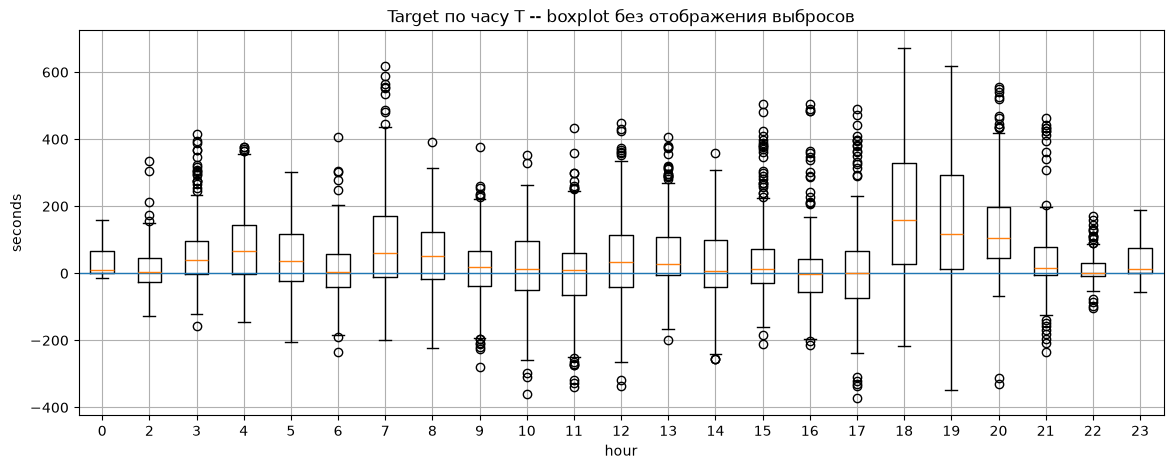

In [70]:
hours = sorted(eda_labels.hour.unique())
values = [eda_labels.loc[eda_labels.hour == hour, 'target_delay_s'] for hour in hours]

eda_fig, eda_ax = plt.subplots(figsize=(14, 5))
eda_ax.boxplot(values, tick_labels=hours, showfliers=True)
eda_ax.axhline(0, linewidth=1)
eda_ax.set_title('Target по часу T -- boxplot без отображения выбросов')
eda_ax.set_xlabel('hour')
eda_ax.set_ylabel('seconds')
plt.show()

Распределение target заметно меняется по времени суток, но число точек по часам неодинаково. Поэтому час полезно добавить как циклический признак (`sin/cos`), а локальные различия оценивать уже на test. Для редких часов средние сами по себе нестабильны.

## 14. Итоги EDA и гипотезы для feature engineering

1. **`cur_dev_s` -- главный baseline**, но его MAE около 93 секунд, а residual остается широким. Проверю и прямое предсказание `target_delay_s`, и residual-постановку.
2. **Свежесть телеметрии важна отдельно от ее значений** -- нужны возраст последнего пакета, возраст последней валидной GPS-точки, gaps, `receive_lag_s`, доля исторических/невалидных пакетов.
3. **Нужны временные окна перед `T`** -- mean/median/std/min/max/quantiles, тренды и изменения скорости, курса, расстояния и качества GPS за несколько горизонтов.
4. **Heavy tails выражены явно** -- для `speed`, `alt`, gaps и lag проверю robust-агрегации и clipping только внутри производных признаков, `log1p`/signed-log и степенные преобразования. Пороги fit'ятся только по train.
5. **Физические признаки приоритетны** -- расстояние до target, bearing, разница курса и направления на target, скорость сближения, путь/displacement, tortuosity, требуемая скорость до планового времени, ETA margin.
6. **Расписание дает дополнительную геометрию и последовательность** -- интервалы до соседних приездов, положение target в локальной последовательности, расстояния между остановками. `time_fact_begin` запрещен.
7. **`manual_fill` связан с распределением задержек** и доступен из расписания -- проверю его как признак, но не буду считать эффект причинным.
8. **Одна последняя GPS-точка объясняет target слабо** -- главный сигнал ожидаю из динамики окна и взаимодействий с расписанием.
9. **Синтетика доминирует в train и зависима от real-траекторий** -- row-wise random split использовать нельзя. Основную оценку делаю на отдельном real test.
10. **Временной контекст заметен** -- добавлю час и другие календарные признаки в циклической форме.
11. **Сырые ID использовать осторожно** -- `target_stop_id` идентифицирует конкретное приезд и плохо переносится. Приоритет у геометрии, частот, локального контекста и физически интерпретируемых признаков.
12. Все признаки для точки `(tr_id, T)` строю только из информации, доступной к `T`, и одинаково вычисляю для train/test/validate.